# Exercise 1.4 — Classify photos with a CNN (CIFAR-10) — **solution**

Worked answers for `Exercise 1.4.ipynb`.

CIFAR-10: 60,000 **colour** images, 32×32 px, 10 classes. Harder than MNIST: colour
channels, varied backgrounds, real objects. Dense layers alone struggle — this is where
**convolutional** layers earn their keep.

Training is much heavier than MNIST. In Colab switch on the GPU first:
**Runtime → Change runtime type → GPU**.

In [1]:
!pip install tensorflow matplotlib numpy scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# --- macOS certificate fix (safe no-op elsewhere) ---
# keras.datasets.*.load_data() downloads over HTTPS. The python.org macOS build
# ships without a default CA bundle, so the download fails with
# "CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate".
# Point Python at certifi's CA bundle. Harmless on Colab/Linux/Windows.
import os, certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())

'/Users/au263437/workspace/hih/_TinyML/Grundfoss/raw/tinyml-course_v2/exercises/.venv/lib/python3.11/site-packages/certifi/cacert.pem'

## Step 1 — Load and look

**Answers:** the input is `(50000, 32, 32, 3)` — a **channel** dimension has appeared.
MNIST was `(60000, 28, 28)`, one implicit grayscale channel; here every pixel is three
numbers, so a CIFAR image is 3072 values against MNIST's 784.

`y_train` comes back as `(50000, 1)`, a column vector rather than the flat `(50000,)`
MNIST gives you. Keras tolerates it, but `confusion_matrix` and any indexing you do will
be cleaner if you `.ravel()` it — so we do that immediately.

And at 32×32 you will misclassify some of these yourself. That is worth noticing before
you judge the model's 70 %.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

keras.utils.set_random_seed(42)

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train, y_test = y_train.ravel(), y_test.ravel()      # (n, 1) -> (n,)

print("x_train:", x_train.shape, x_train.dtype, "min", x_train.min(), "max", x_train.max())
print("y_train:", y_train.shape, " x_test:", x_test.shape, " y_test:", y_test.shape)
print("samples per class:", np.bincount(y_train))

x_train: (50000, 32, 32, 3) uint8 min 0 max 255
y_train: (50000,)  x_test: (10000, 32, 32, 3)  y_test: (10000,)
samples per class: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


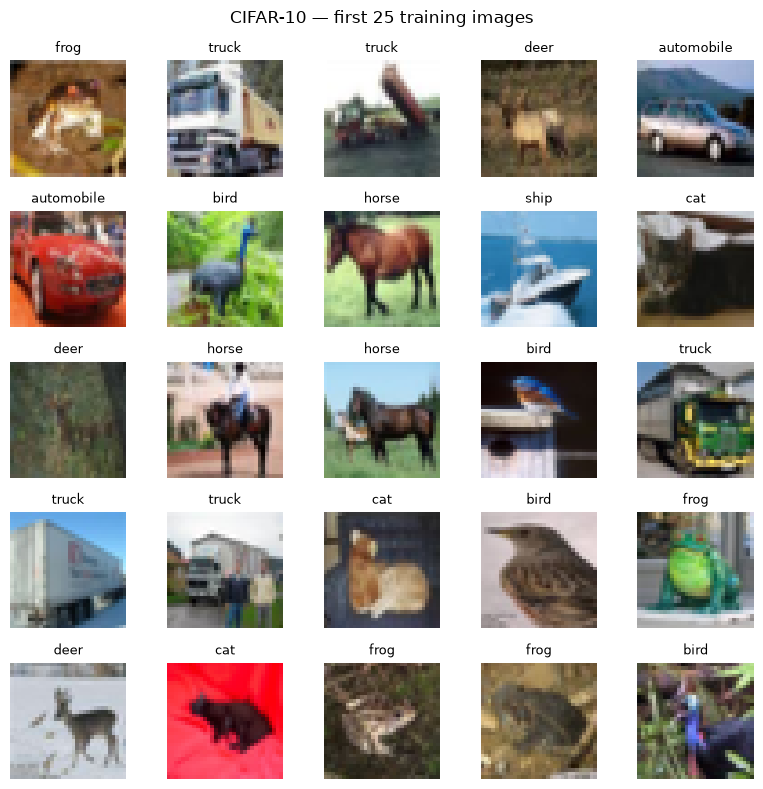

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, img, label in zip(axes.ravel(), x_train, y_train):
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
fig.suptitle("CIFAR-10 — first 25 training images")
fig.tight_layout()

## Step 2 — Normalise

Same move as MNIST: pixels to floats in `[0, 1]`. Three channels this time, and the code
does not change at all — which is the point.

In [5]:
x_train = (x_train / 255.0).astype("float32")
x_test  = (x_test  / 255.0).astype("float32")
print("range now:", x_train.min(), "to", x_train.max(), x_train.dtype)

range now: 0.0 to 1.0 float32


## Step 3 — Build the CNN

**Answers:** the first `Conv2D(32, 3)` has `3×3×3 × 32 + 32` = **896** parameters — 32
filters, each a 3×3 patch across 3 colour channels, plus one bias each. A `Dense(32)` on
the flattened 3072-pixel input would have `3072 × 32 + 32` = **98,336**: over 100× more,
for a layer that would still have no idea that two pixels next to each other are related.

That ratio is the entire argument for convolution. The filter is *shared* across every
position in the image, so the parameter count depends on the filter size and the number
of filters — not on the image size. It also builds in the assumption that a useful
pattern is a local one, and means the same edge detector works wherever the edge appears.

Note where the parameters actually pile up in the summary: the `Dense(64)` after
`Flatten` has 1024×64+64 = 65,600 of the model's ~122k. The convolutions do most of the
work with a fraction of the weights.

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

conv1 = 3 * 3 * 3 * 32 + 32
dense_equivalent = 32 * 32 * 3 * 32 + 32
print(f"\nfirst Conv2D(32, 3): {conv1} parameters")
print(f"a Dense(32) on the raw 3072 pixels: {dense_equivalent} parameters"
      f"  ({dense_equivalent / conv1:.0f}x more)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


first Conv2D(32, 3): 896 parameters
a Dense(32) on the raw 3072 pixels: 98336 parameters  (110x more)


## Step 4 — Train

**Answers:** ~68 % test accuracy after 10 epochs, against 10 % for guessing. Training
accuracy is still climbing — 82 % by epoch 10 — but validation accuracy peaked around
epoch 5 at ~70 % and the validation *loss* has been rising ever since. Everything after
epoch 5 is memorisation, and this is where early stopping would cut you off.

Why does this overfit so much earlier than MNIST? Five reasons stacked: 50k training
images instead of 60k, each one 4× more input values, ten classes with far more
within-class variation (a "dog" can be any breed, pose, background), no data augmentation,
and a model with ~8× the parameters of the MNIST one. More capacity, harder problem, less
data per unit of variation.

"Good" depends entirely on what you are doing with it. 70 % would be unusable for sorting
photos and perfectly fine as one vote among several sensors.

In [7]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test), verbose=2)

Epoch 1/10
1563/1563 - 9s - 5ms/step - accuracy: 0.4585 - loss: 1.4841 - val_accuracy: 0.5714 - val_loss: 1.1926
Epoch 2/10
1563/1563 - 9s - 6ms/step - accuracy: 0.6089 - loss: 1.1018 - val_accuracy: 0.6386 - val_loss: 1.0189
Epoch 3/10
1563/1563 - 10s - 6ms/step - accuracy: 0.6675 - loss: 0.9519 - val_accuracy: 0.6736 - val_loss: 0.9357
Epoch 4/10
1563/1563 - 11s - 7ms/step - accuracy: 0.7018 - loss: 0.8530 - val_accuracy: 0.6886 - val_loss: 0.9116
Epoch 5/10
1563/1563 - 12s - 8ms/step - accuracy: 0.7302 - loss: 0.7750 - val_accuracy: 0.6989 - val_loss: 0.8960
Epoch 6/10
1563/1563 - 12s - 8ms/step - accuracy: 0.7522 - loss: 0.7126 - val_accuracy: 0.6964 - val_loss: 0.9082
Epoch 7/10
1563/1563 - 12s - 8ms/step - accuracy: 0.7704 - loss: 0.6616 - val_accuracy: 0.6924 - val_loss: 0.9368
Epoch 8/10
1563/1563 - 12s - 8ms/step - accuracy: 0.7875 - loss: 0.6175 - val_accuracy: 0.6874 - val_loss: 0.9625
Epoch 9/10
1563/1563 - 13s - 8ms/step - accuracy: 0.8004 - loss: 0.5746 - val_accuracy: 0.

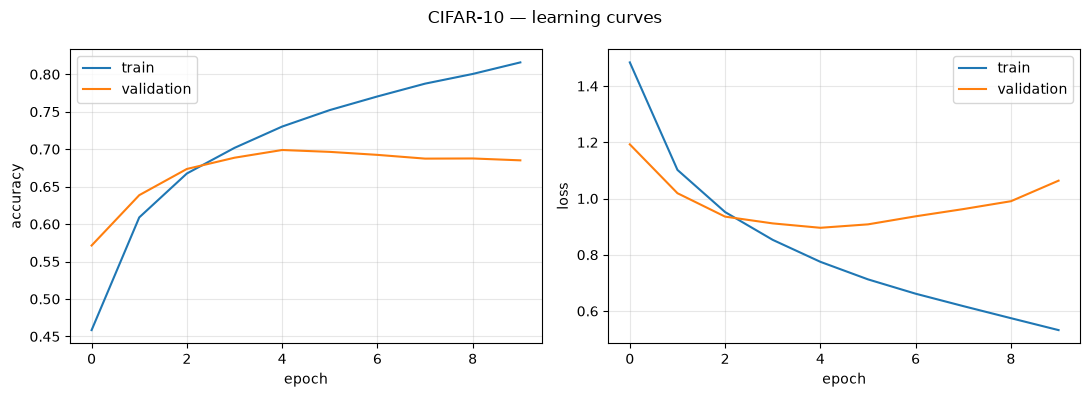

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="validation")
ax1.set_xlabel("epoch"); ax1.set_ylabel("accuracy"); ax1.legend(); ax1.grid(alpha=.3)
ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="validation")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss"); ax2.legend(); ax2.grid(alpha=.3)
fig.suptitle("CIFAR-10 — learning curves")
fig.tight_layout()

## Step 5 — Where does it go wrong?

**Answers:** the confusions are sensible, not bizarre. In this run the worst are
**bird→deer** (159), **cat→deer** (144), **dog→cat** (135), **dog→horse** and
**truck→automobile** — the animal cluster mixing with itself, plus the two classes of
box on wheels. The model has learned something real about shape and colour; it just
cannot separate two four-legged brown animals at 32×32.

Those are largely the same mistakes you made looking at the grid in Step 1. When a
model's errors look like human errors on the same input, the input is usually the limit —
not the architecture.

test loss 1.0636   test accuracy 0.6851
      bird predicted as deer       159 times
       cat predicted as deer       144 times
       dog predicted as cat        135 times
       dog predicted as horse      123 times
     truck predicted as automobile 123 times


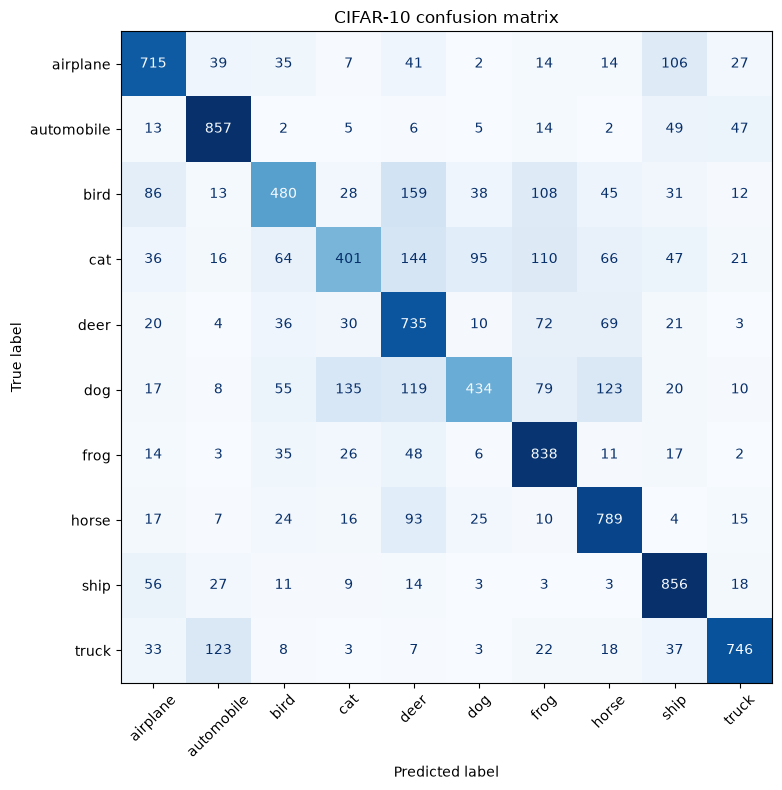

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"test loss {test_loss:.4f}   test accuracy {test_acc:.4f}")

y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False,
                                                        cmap="Blues", xticks_rotation=45)
ax.set_title("CIFAR-10 confusion matrix")
fig.tight_layout()

off = cm.copy()
np.fill_diagonal(off, 0)
for t, p in zip(*np.unravel_index(np.argsort(off, axis=None)[-5:][::-1], off.shape)):
    print(f"{CLASSES[t]:>10} predicted as {CLASSES[p]:<10} {off[t, p]} times")

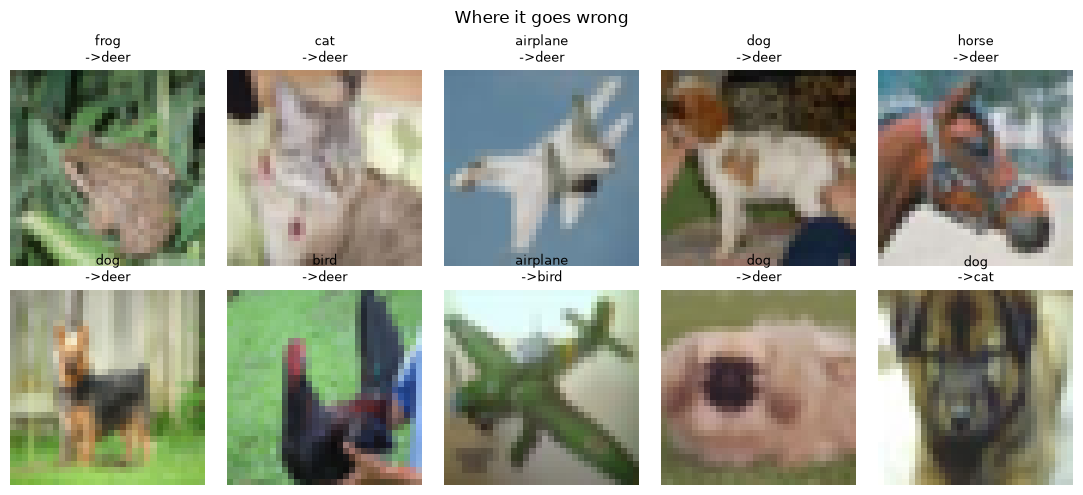

In [10]:
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, idx in zip(axes.ravel(), wrong[:10]):
    ax.imshow(x_test[idx])
    ax.set_title(f"{CLASSES[y_test[idx]]}\n->{CLASSES[y_pred[idx]]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Where it goes wrong")
fig.tight_layout()

## Step 6 — Would it fit on the device?

**Answer:** the weights are the easy part — ~122k parameters is ~478 KB at float32 and
~120 KB at int8, so a quantised version fits the 1 MB flash without drama.

RAM is what bites. The first convolution's output is 30×30×32 = 28,800 floats = **113 KB**,
and you need the input and one output tensor live at the same time — on a 256 KB device
that is most of your budget before the runtime, the stack and anything else the firmware
does. Quantising to int8 cuts that to ~28 KB and makes it plausible.

What to cut first: fewer filters in the first conv layer, and downsample earlier
(stride 2, or pool immediately) so the big tensors never exist. Note that this has nothing
to do with the parameter count — it is the *activations*. That distinction is Module 9's
whole subject.

In [11]:
params = model.count_params()
print(f"{params} parameters")
print(f"float32 weights: {params * 4 / 1024:7.1f} KB")
print(f"int8 weights:    {params * 1 / 1024:7.1f} KB")

print("\nactivation tensors:")
for layer in model.layers:
    shape = layer.output.shape[1:]                     # drop the batch dimension
    n = int(np.prod(shape))
    print(f"  {layer.name:<16} {str(tuple(shape)):<16} {n:>7} values"
          f"  = {n * 4 / 1024:7.1f} KB float32  /{n / 1024:7.1f} KB int8")

print("\nRAK4631 budget: 1024 KB flash / 256 KB RAM")

122570 parameters
float32 weights:   478.8 KB
int8 weights:      119.7 KB

activation tensors:
  conv2d           (30, 30, 32)       28800 values  =   112.5 KB float32  /   28.1 KB int8
  max_pooling2d    (15, 15, 32)        7200 values  =    28.1 KB float32  /    7.0 KB int8
  conv2d_1         (13, 13, 64)       10816 values  =    42.2 KB float32  /   10.6 KB int8
  max_pooling2d_1  (6, 6, 64)          2304 values  =     9.0 KB float32  /    2.2 KB int8
  conv2d_2         (4, 4, 64)          1024 values  =     4.0 KB float32  /    1.0 KB int8
  flatten          (1024,)             1024 values  =     4.0 KB float32  /    1.0 KB int8
  dense            (64,)                 64 values  =     0.2 KB float32  /    0.1 KB int8
  dense_1          (10,)                 10 values  =     0.0 KB float32  /    0.0 KB int8

RAK4631 budget: 1024 KB flash / 256 KB RAM


## Observe & discuss — the short answers

- **Input shape:** `(32, 32, 3)` — height, width, **channels**. 3072 values per image
  against MNIST's 784.
- **Convolution and pooling:** convolution applies a small learned filter at every
  position, so the same feature detector is reused across the image and the parameter
  count no longer scales with image size. Pooling halves the resolution, which shrinks
  the tensors and lets later layers see a larger part of the picture per filter.
- **Epochs / what is good:** ~10 epochs gets 65-70 %; the curve is still rising but the
  validation loss has stopped improving. "Good" is defined by the decision the model
  feeds, never by the number alone.
- **ReLU in C:**
  ```c
  static inline float relu(float x) { return x > 0.0f ? x : 0.0f; }
  ```
  One comparison and a select — no exponentials, no division, no lookup table. That is
  exactly why it won over `tanh` and `sigmoid` for microcontroller inference.